# S3 · Other views of the class and cluster chemistry

Figures behind sections 3, 4 and 6 of the main notebook that the paper does not show.

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")   # library deprecation notices only
%config InlineBackend.figure_format = 'png'

REPO = Path("../../../..").resolve()
sys.path.append(str(REPO / "Downstream_Analysis/scripts"))
sys.path.append(str(REPO / "scripts"))
import activation_code as ac
import activation_figures as af
from plotting_functions import FIGSIZE, custom_plots

plt.rcParams.update(custom_plots())

PROBABILITIES = REPO / "Downstream_Analysis/predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv"
M2OR_PAIRS = REPO / "Model_Inputs/Data_Preparation/processed/m2or_pairs_model.csv"
ODOURS = REPO / "Chemicals/processed_data/m2or_inchi_odors_smiles.csv"
PATHWAYS = REPO / "Chemicals/processed_data/ligand_pathways.csv"
FASTA = REPO / "Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa"
CLASSES = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_OR_classes.csv"
TREE = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_MFP_reorder.tree"

FIGURES = Path("Figures")
TABLES = Path("Tables")
MAIN_TABLES = Path("../Tables")     # written by ../figure2_activation_code.ipynb
FIGURES.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)
NAME = "hybrid_density"

In [2]:
data = ac.load_activation_data(PROBABILITIES, M2OR_PAIRS, FASTA)
smiles_by_odorant, tags_by_odorant = ac.odour_tags(M2OR_PAIRS, ODOURS, data.odorant_ids)
class_of = ac.receptor_classes(CLASSES)
print(f"density {data.fill.density:.4%}   cut {data.fill.cut:.4f} (an output of the fill)")

density 2.7453%   cut 0.8917 (an output of the fill)


## Ligands per receptor: every receptor, and as a density

The same counts as Fig. 2b. The density keeps orphans as a separate bar at 0; the curve is
over the receptors with at least one ligand, so bar plus curve is 1 for each class.

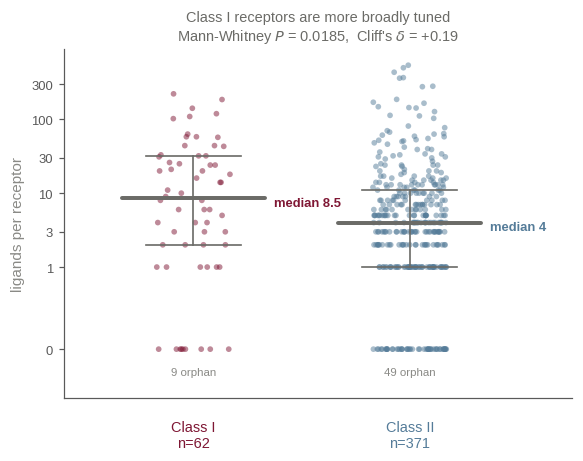

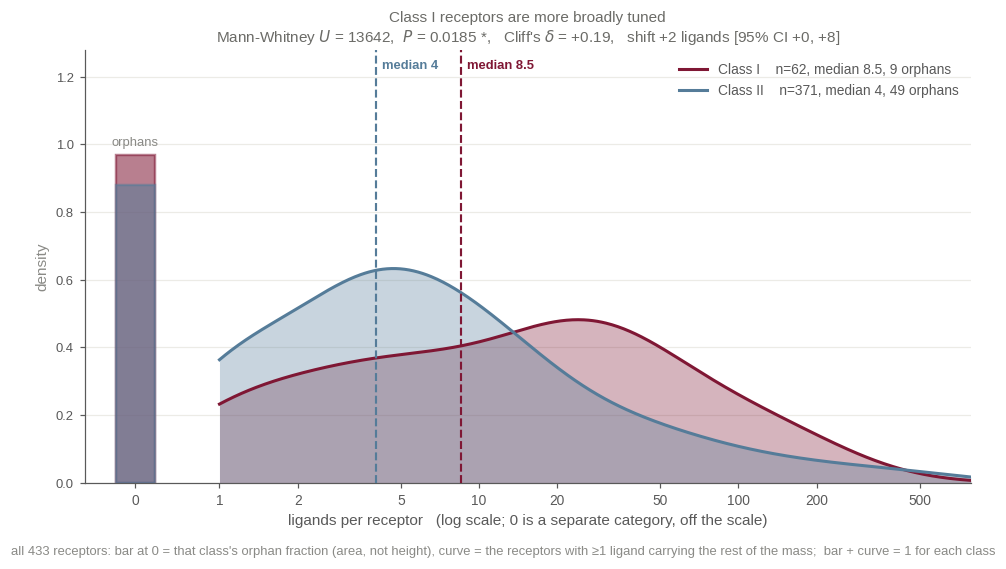

In [3]:
breadth = ac.tuning_breadth(data.hybrid, data.receptor_ids, class_of)
af.breadth_strip(breadth, FIGURES / "class_tuning_breadth.svg")
af.breadth_density(breadth, FIGURES / "class_tuning_breadth_density.svg")

## Descriptors of the three class sets

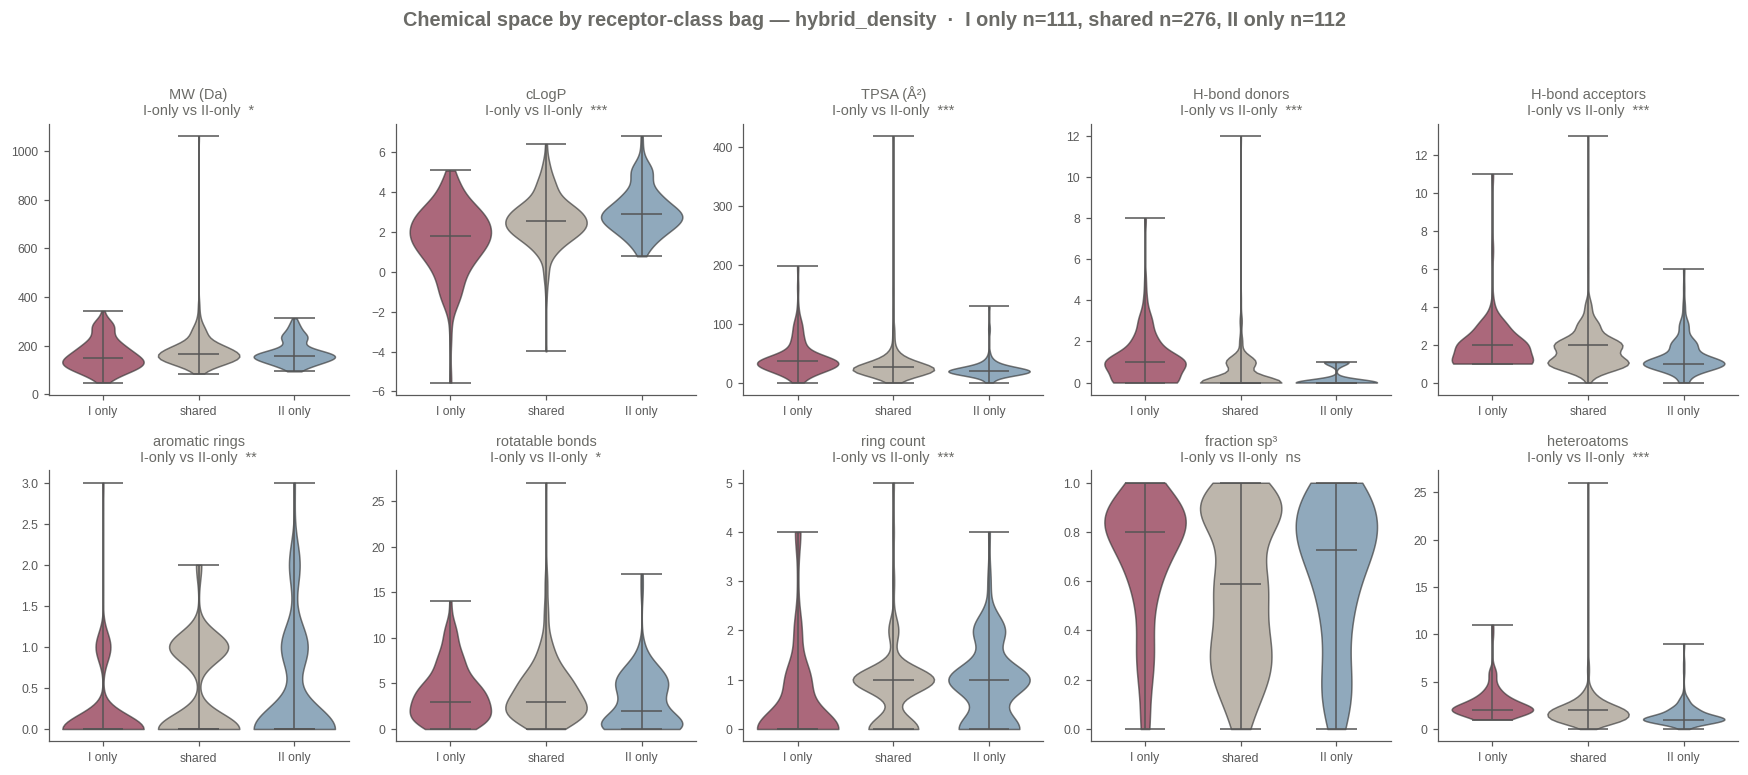

In [4]:
groups, rate, rate_I, rate_II, in_I, in_II = ac.class_partition(data.hybrid, data.receptor_ids, class_of)
is_class_I = np.array([class_of[r] == "I" for r in data.receptor_ids])
class_descriptors = ac.class_set_descriptors(data.odorant_ids, smiles_by_odorant, groups, rate_I, rate_II, in_I, in_II)
af.class_descriptor_violins(class_descriptors, NAME, FIGURES / f"chemspace_{NAME}.svg", show=True)

## Fold change between the classes

Class I set over Class II set, per property. Twice: the full sets, which share 276 odorants,
and the exclusive sets. With overlapping sets the shared odorants are held on both sides and
only the exclusive labels are permuted; the bootstrap draws the shared block once for both.

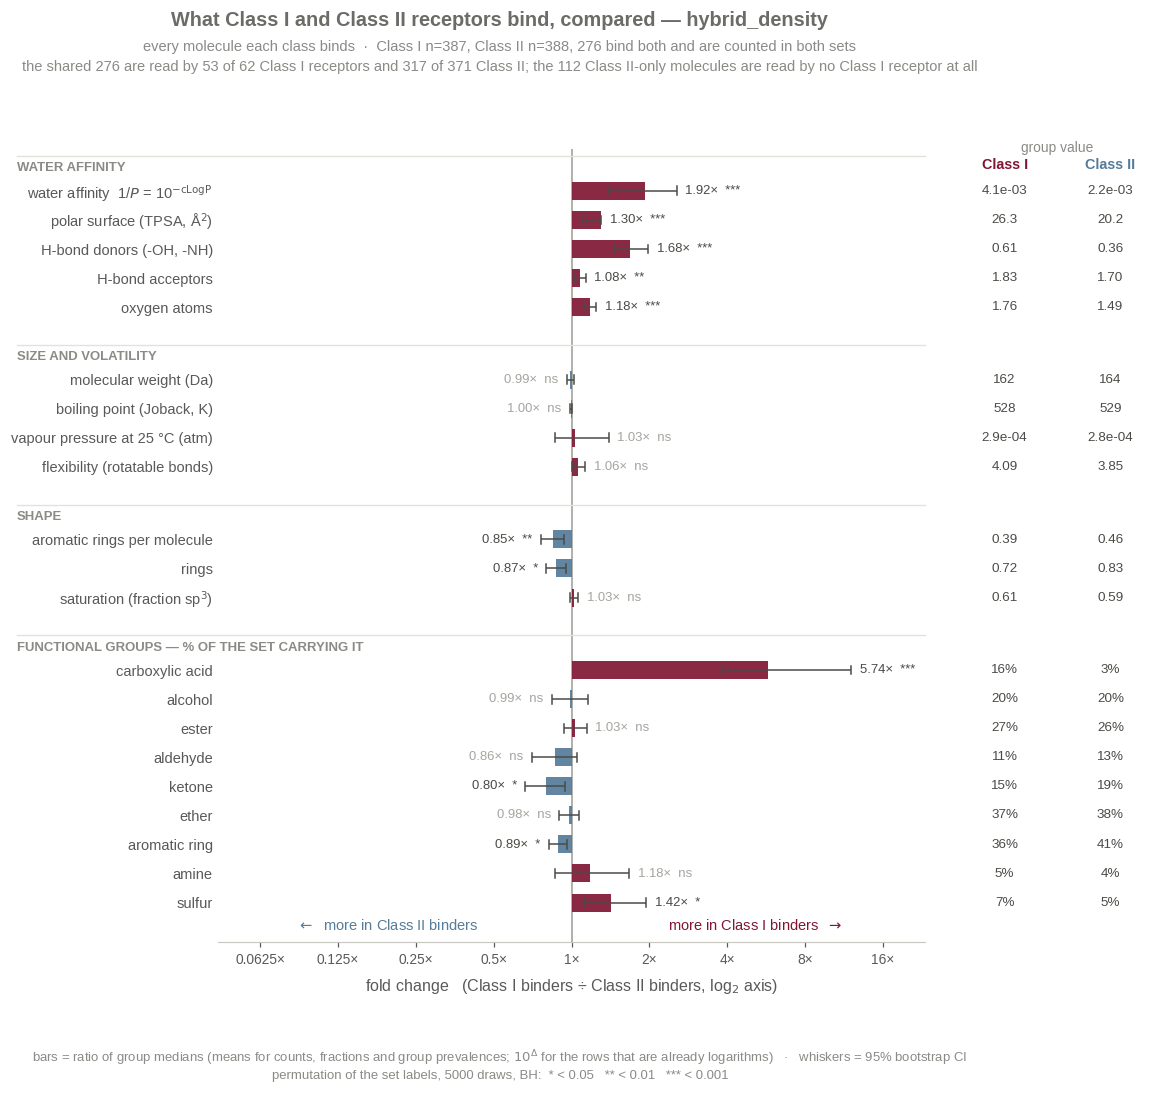

  chemspace_hybrid_density_effects           WaterAff 1.92x***  TPSA 1.30x***  HBD 1.68x***  HBA 1.08x**  OxygenAtoms 1.18x***  AromaticRings 0.85x**  RingCount 0.87x*  carboxylic acid 5.74x***  ketone 0.80x*  aromatic ring 0.89x*  sulfur 1.42x*


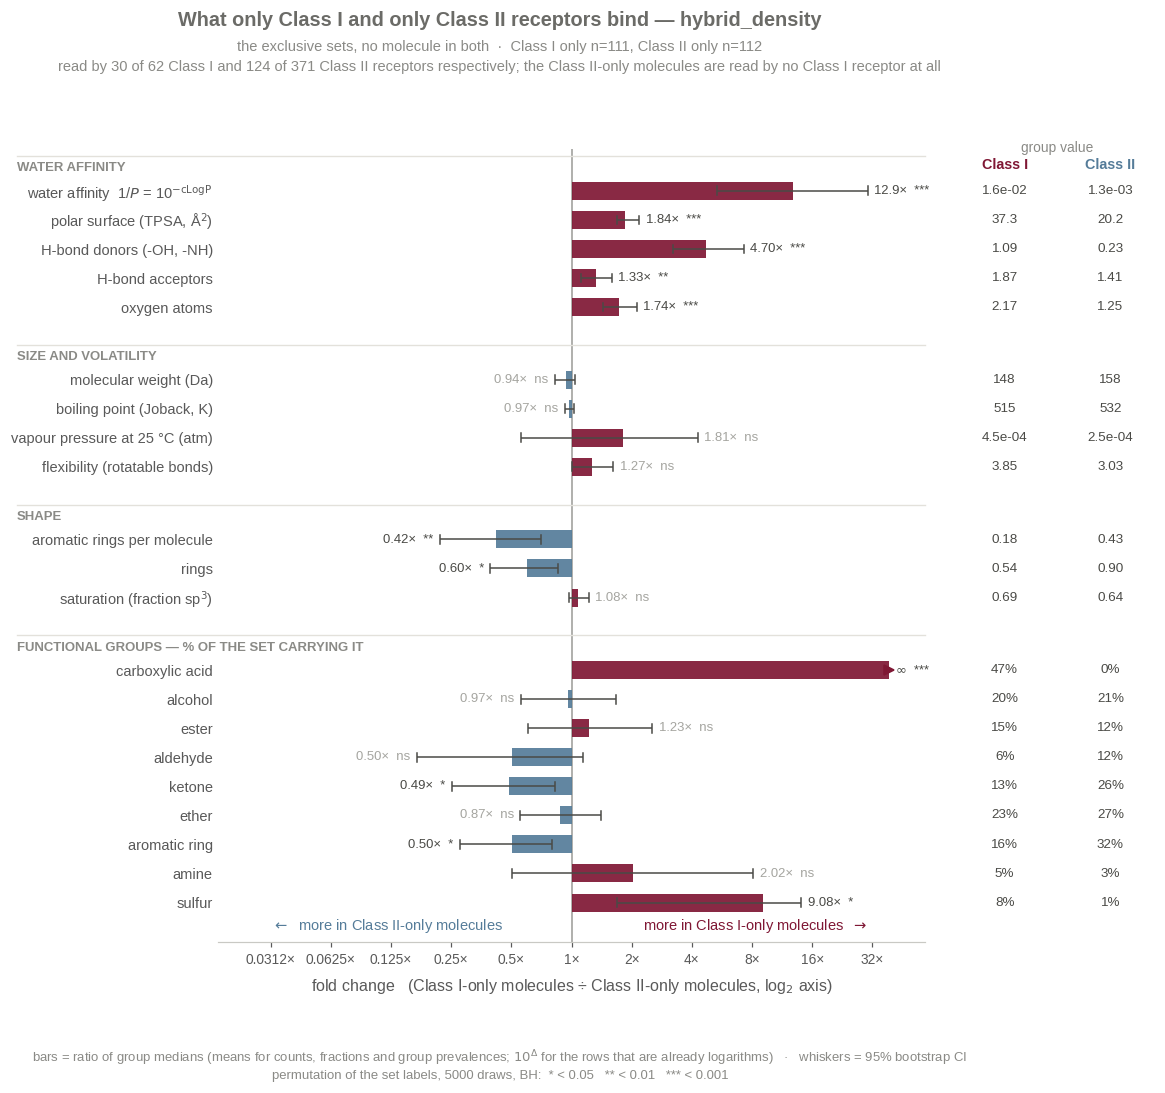

  chemspace_hybrid_density_effects_exclusive WaterAff 12.86x***  TPSA 1.84x***  HBD 4.70x***  HBA 1.33x**  OxygenAtoms 1.74x***  AromaticRings 0.42x**  RingCount 0.60x*  carboxylic acid infx***  ketone 0.49x*  aromatic ring 0.50x*  sulfur 9.08x*


,property,fold_change_I_over_II,ci_lo,ci_hi,class_I,class_II,summary,perm_p,perm_q,cliffs_delta
0,WaterAff,12.864710,5.328439,30.315082,0.016429,0.001277,antilog,0.000200,0.000840,0.514961
1,TPSA,1.843796,1.687593,2.185120,37.300000,20.230000,median,0.000200,0.000840,0.658301
2,HBD,4.695773,3.205087,7.264865,1.090090,0.232143,mean,0.000200,0.000840,0.488900
3,HBA,1.328316,1.117916,1.587729,1.873874,1.410714,mean,0.000800,0.002799,0.277590
4,OxygenAtoms,1.736937,1.437809,2.114133,2.171171,1.250000,mean,0.000200,0.000840,0.512709
5,MolWt,0.936456,0.823970,1.038379,148.227000,158.285000,median,0.082983,0.134050,-0.182030
6,Tb,0.968462,0.923733,1.030945,515.430000,532.215000,median,0.236153,0.295176,-0.081162
7,VP,1.814628,0.559440,4.271363,0.000447,0.000246,antilog,0.238952,0.295176,0.081162
8,RotBonds,1.270935,1.004505,1.621264,3.846847,3.026786,mean,0.049790,0.087133,0.181869
9,AromaticRings,0.420420,0.220147,0.700701,0.180180,0.428571,mean,0.002599,0.007798,-0.171493


In [5]:
n_I, n_II = int(is_class_I.sum()), int((~is_class_I).sum())
shared_readers = ac.receptors_reading(data.hybrid, is_class_I, in_I & in_II)
only_I_readers = ac.receptors_reading(data.hybrid, is_class_I, in_I & ~in_II)
only_II_readers = ac.receptors_reading(data.hybrid, is_class_I, ~in_I & in_II)
full_I, full_II = class_descriptors.in_I.values, class_descriptors.in_II.values

af.fold_change_figure(
    class_descriptors, full_I, full_II, f"What Class I and Class II receptors bind, compared — {NAME}",
    f"every molecule each class binds  ·  Class I n={full_I.sum()}, Class II n={full_II.sum()}, "
    f"{(full_I & full_II).sum()} bind both and are counted in both sets\n"
    f"the shared {(full_I & full_II).sum()} are read by {shared_readers[0]} of {n_I} Class I receptors and "
    f"{shared_readers[1]} of {n_II} Class II; the {int((full_II & ~full_I).sum())} Class II-only molecules are "
    f"read by no Class I receptor at all",
    "Class I binders", "Class II binders", FIGURES / f"chemspace_{NAME}_effects.svg",
    TABLES / f"chemspace_{NAME}_effects.csv", show=True)

af.fold_change_figure(
    class_descriptors, full_I & ~full_II, full_II & ~full_I, f"What only Class I and only Class II receptors bind — {NAME}",
    f"the exclusive sets, no molecule in both  ·  Class I only n={(full_I & ~full_II).sum()}, "
    f"Class II only n={(full_II & ~full_I).sum()}\n"
    f"read by {only_I_readers[0]} of {n_I} Class I and {only_II_readers[1]} of {n_II} Class II receptors respectively; "
    f"the Class II-only molecules are read by no Class I receptor at all",
    "Class I-only molecules", "Class II-only molecules", FIGURES / f"chemspace_{NAME}_effects_exclusive.svg",
    TABLES / f"chemspace_{NAME}_effects_exclusive.csv", show=True)

## Odour descriptors of the full class sets

Percentages only: the two sets share 276 odorants, so a per-descriptor Fisher test would not be
valid. The numbers are in `../Tables/odour_tags_hybrid_density_percentages.csv`.

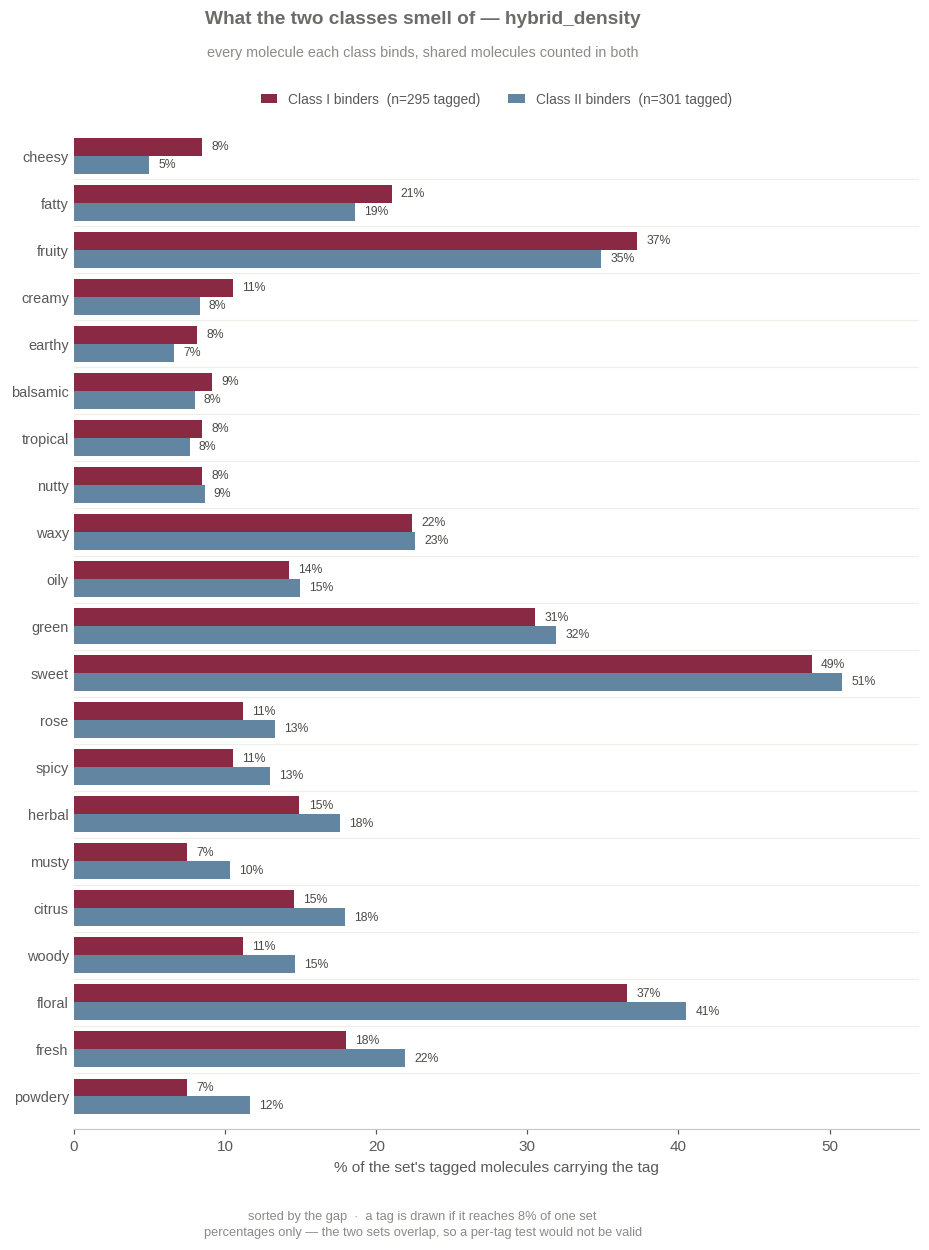

In [6]:
table, shown, n_tagged_I, n_tagged_II = ac.tag_percentages(in_I, in_II, data.odorant_ids, tags_by_odorant)
af.tag_percent_figure(shown, n_tagged_I, n_tagged_II, f"What the two classes smell of — {NAME}",
                      "every molecule each class binds, shared molecules counted in both", "Class I binders",
                      "Class II binders", FIGURES / f"odour_tags_{NAME}.svg", show=True)

## Descriptors of the six clusters

cluster sizes [70, 100, 127, 214, 68, 108]


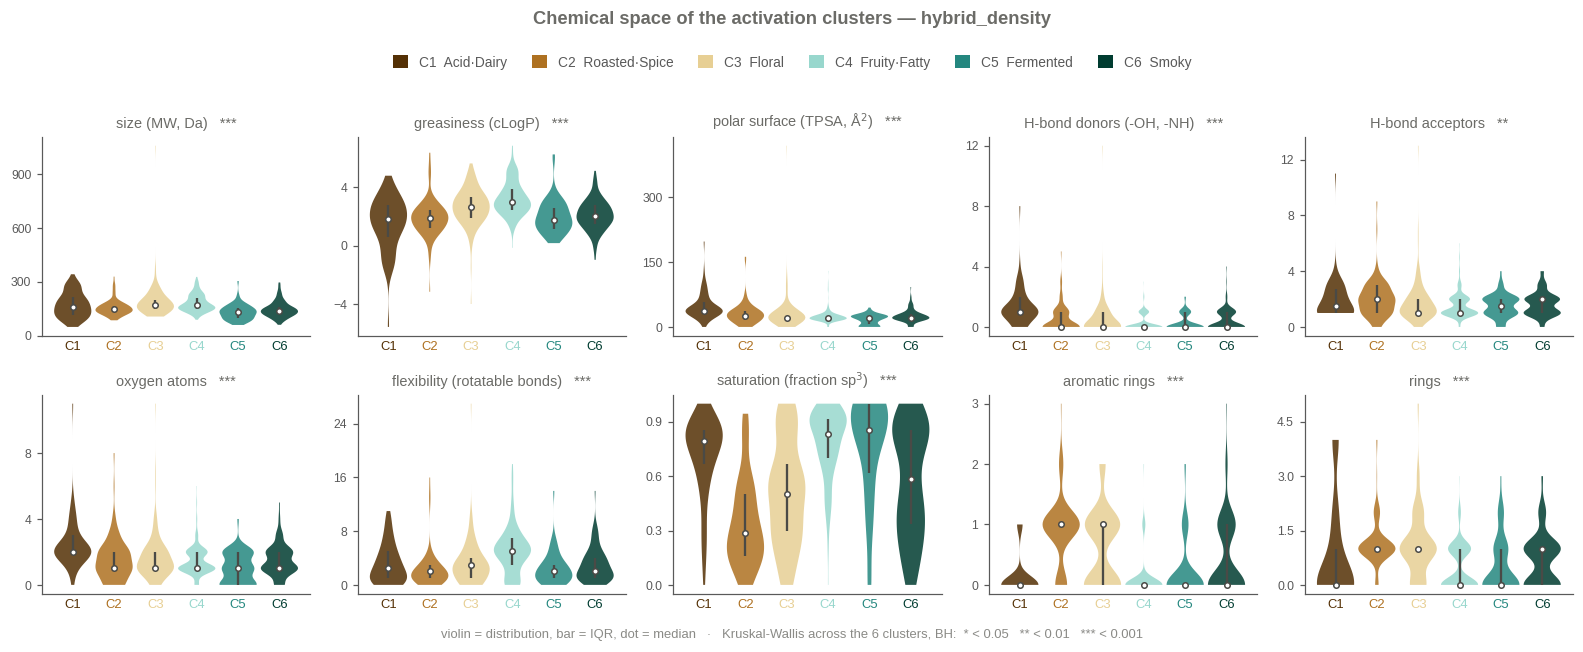

In [7]:
clustered_ids, clustered_matrix, labels = ac.cluster_odorants(data.hybrid, data.odorant_ids)
enrichment = ac.tag_enrichment(clustered_ids, labels, tags_by_odorant)
info, display_order = ac.name_clusters(enrichment, labels)
print("cluster sizes", [info[c]["size"] for c in display_order])

cluster_descriptors = ac.odorant_descriptors(clustered_ids, smiles_by_odorant, labels)
af.cluster_descriptor_violins(cluster_descriptors, info, display_order, NAME,
                              FIGURES / f"chemspace_clusters_{NAME}.svg", show=True)